In [8]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

In [3]:
import matplotlib as mpl
from matplotlib import rcParams
import numpy as np
import torch

from grid_pattern_formation.evals.core import build_eval_context
from einops import rearrange
from functools import reduce
from torch import nn
import json
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations


def editable_matplotlib():
    rcParams.update({'figure.autolayout': False})
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['ps.fonttype'] = 42

editable_matplotlib()

def get_layer_by_name(model: nn.Module, layer_name: str):
    """Retrieve a pytorch layer from a model by it's name"""
    if layer_name != "":
        names = layer_name.split(sep=".")
    else:
        return model
    return reduce(getattr, names, model)

class ForwardHook:
    def __init__(self, model, hook_layer_name: str, postprocess_fn: callable=None):
        layer = get_layer_by_name(model=model, layer_name=hook_layer_name)
        self.hook = layer.register_forward_hook(self.hook_fn)
        self.input = None
        self._output = None
        self.postprocess_fn = postprocess_fn
        print(f"\033[94mRegistered forward hook on layer: {hook_layer_name}: {layer}\033[0m")

    def hook_fn(self, module, input, output):
        self.input = input
        self._output = output

    @property
    def output(self):
        if self.postprocess_fn is not None:
            return self.postprocess_fn(self._output)
        return self._output

    def close(self):
        self.hook.remove()

device = "cpu"
dtype = torch.float32

baseline_ctx = build_eval_context(
    checkpoint_path="../checkpoints/replicate_baseline_colab_orig_rmsprop_alive.pth",
    config_path="../configs/replicate_baseline_colab_orig_rmsprop_alive.yaml",
    results_root="../results/phase_analysis",
)
topo_ctx = build_eval_context(
    checkpoint_path="../checkpoints/cos_decay_hw4_final_model.pth",
    config_path="../configs/topo_cos_decay_hw4.yaml",
    results_root="../results/phase_analysis",
)

baseline_ctx.model.eval().to(device=device, dtype=dtype)
topo_ctx.model.eval().to(device=device, dtype=dtype) 
print(baseline_ctx.model)

hook_baseline = ForwardHook(
    model=baseline_ctx.model,
    hook_layer_name="RNN",
)

hook_topo = ForwardHook(
    model=topo_ctx.model,
    hook_layer_name="RNN",
)

num_samples = 1024
gen = baseline_ctx.trajectory_generator.get_generator(batch_size=num_samples)

inputs, pc_outputs, pos = next(gen)

with torch.no_grad():
    logits = baseline_ctx.model.predict(inputs)
    logits = topo_ctx.model.predict(inputs)

activations_baseline, _ = hook_baseline.output
activations_topo, _ = hook_topo.output

print(activations_baseline.shape, activations_topo.shape)


topo_map = rearrange(
    activations_topo,
    'seq batch (h w) -> (seq batch) h w',
    h=64,
    w=64
)

baseline_map = rearrange(
    activations_baseline,
    'seq batch (h w) -> (seq batch) h w',
    h=64,
    w=64
)

def compute_distance_correlation_data(activity_map: np.ndarray, name: str, max_pairs: int = 500_000):
    """
    For a 3D activity map of shape (samples, H, W), compute pairwise
    Euclidean distance vs Pearson correlation across all spatial positions.
    
    Returns a dict with 'distances' and 'correlations' lists.
    """
    n_samples, H, W = activity_map.shape
    
    # Flatten spatial dims: shape (H*W, n_samples)
    # Each spatial position becomes a vector of activations across samples
    flat = activity_map.reshape(n_samples, H * W).T  # (H*W, n_samples)
    
    n_positions = H * W  # 64*64 = 4096 positions
    
    # Build grid coordinates for each position
    ys, xs = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    coords = np.stack([ys.ravel(), xs.ravel()], axis=1).astype(np.float32)  # (H*W, 2)
    
    # Z-score each position's activation vector (for Pearson correlation)
    mean = flat.mean(axis=1, keepdims=True)
    std = flat.std(axis=1, keepdims=True) + 1e-8
    flat_normed = (flat - mean) / std  # (H*W, n_samples)
    
    # Sample pairs if too many
    all_pairs = list(combinations(range(n_positions), 2))
    print(f"[{name}] Total pairs: {len(all_pairs):,}")
    
    if len(all_pairs) > max_pairs:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(all_pairs), size=max_pairs, replace=False)
        sampled_pairs = [all_pairs[i] for i in idx]
        print(f"[{name}] Subsampled to {max_pairs:,} pairs")
    else:
        sampled_pairs = all_pairs
    
    pairs_arr = np.array(sampled_pairs)  # (N_pairs, 2)
    i_idx = pairs_arr[:, 0]
    j_idx = pairs_arr[:, 1]
    
    # Euclidean distances between grid positions
    diff = coords[i_idx] - coords[j_idx]
    distances = np.sqrt((diff ** 2).sum(axis=1))  # (N_pairs,)
    
    # Pearson correlation (dot product of z-scored vectors / n_samples)
    correlations = (flat_normed[i_idx] * flat_normed[j_idx]).mean(axis=1)  # (N_pairs,)
    
    return {
        "distances": distances.tolist(),
        "correlations": correlations.tolist(),
        "H": H,
        "W": W,
        "n_samples": n_samples,
        "n_pairs": len(sampled_pairs),
    }

topo_np = topo_map.cpu().numpy()  # (seq*batch, 64, 64)
baseline_np = baseline_map.cpu().numpy()  # (seq*batch, 64, 64)

print(f"topo_np shape: {topo_np.shape}")
print(f"baseline_np shape: {baseline_np.shape}")

topo_data = compute_distance_correlation_data(topo_np, name="topo", max_pairs=500_000)
baseline_data = compute_distance_correlation_data(baseline_np, name="baseline", max_pairs=500_000)

output = {
    "topo": topo_data,
    "baseline": baseline_data,
}

out_path = "distance_correlation_data.json"
with open(out_path, "w") as f:
    json.dump(output, f)

print(f"Saved to {out_path}")

RNN(
  (encoder): Linear(in_features=512, out_features=4096, bias=False)
  (RNN): RNN(2, 4096, bias=False)
  (decoder): Linear(in_features=4096, out_features=512, bias=False)
  (softmax): Softmax(dim=-1)
)
Registered forward hook on layer: RNN: RNN(2, 4096, bias=False)
Registered forward hook on layer: RNN: RNN(2, 4096, bias=False)
torch.Size([20, 1024, 4096]) torch.Size([20, 1024, 4096])
topo_np shape: (20480, 64, 64)
baseline_np shape: (20480, 64, 64)
[topo] Total pairs: 8,386,560
[topo] Subsampled to 500,000 pairs
[baseline] Total pairs: 8,386,560
[baseline] Subsampled to 500,000 pairs
Saved to distance_correlation_data.json


In [ ]:
# Sorted baseline addition
from grid_pattern_formation.evals.core import get_cached_ratemaps
from grid_pattern_formation.evals.analysis_connectivity import compute_phase_order

RES = 50
N_AVG = 100
Ng = 4096

_, baseline_rm, _, _ = get_cached_ratemaps(baseline_ctx, res=RES, n_avg=N_AVG, ng=Ng)
baseline_order, _ = compute_phase_order(baseline_ctx, baseline_rm, RES)

activations_baseline_np = activations_baseline.cpu().numpy()
baseline_sorted_np = rearrange(
    activations_baseline_np[:, :, baseline_order],
    'seq batch (h w) -> (seq batch) h w',
    h=64,
    w=64,
)
print(f"baseline_sorted_np shape: {baseline_sorted_np.shape}")

baseline_sorted_data = compute_distance_correlation_data(
    baseline_sorted_np, name="baseline_sorted", max_pairs=500_000
)

# Merge into the existing JSON
with open(out_path) as f:
    output = json.load(f)
output["baseline_sorted"] = baseline_sorted_data
with open(out_path, "w") as f:
    json.dump(output, f)
print(f"Added baseline_sorted to {out_path}")

baseline_sorted_np shape: (20480, 64, 64)
[baseline_sorted] Total pairs: 8,386,560
[baseline_sorted] Subsampled to 500,000 pairs
Added baseline_sorted to distance_correlation_data.json


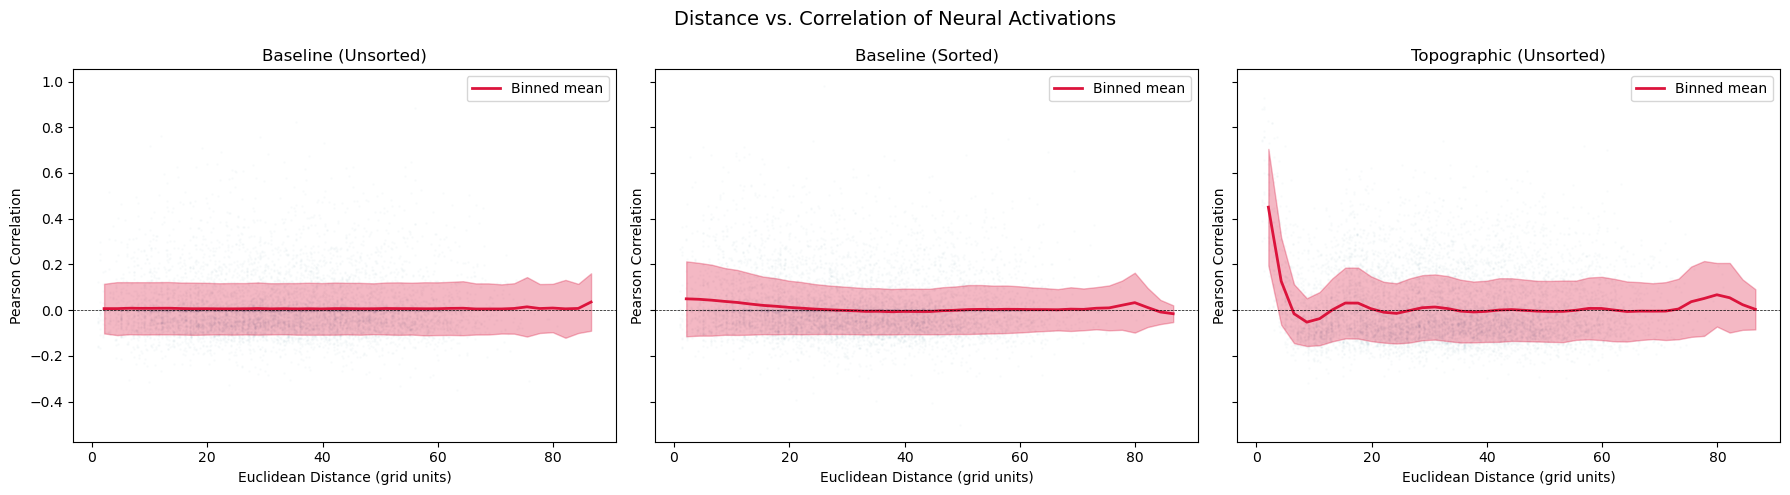

In [9]:
with open("distance_correlation_data.json") as f:
    data = json.load(f)

panels = [
    ("baseline", "Baseline (Unsorted)"),
    ("baseline_sorted", "Baseline (Sorted)"),
    ("topo", "Topographic (Unsorted)"),
]

fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 5), sharey=True)

for ax, (key, label) in zip(axes, panels):
    d = np.array(data[key]["distances"])
    c = np.array(data[key]["correlations"])
    
    # Bin by distance and plot mean ± std
    bins = np.linspace(d.min(), d.max(), 40)
    bin_idx = np.digitize(d, bins)
    bin_centers, means, stds = [], [], []
    for b in range(1, len(bins)):
        mask = bin_idx == b
        if mask.sum() > 10:
            bin_centers.append((bins[b-1] + bins[b]) / 2)
            means.append(c[mask].mean())
            stds.append(c[mask].std())
    
    bin_centers = np.array(bin_centers)
    means = np.array(means)
    stds = np.array(stds)
    
    ax.scatter(d[::50], c[::50], alpha=0.02, s=1, color="steelblue", rasterized=True)
    ax.plot(bin_centers, means, color="crimson", lw=2, label="Binned mean")
    ax.fill_between(bin_centers, means - stds, means + stds, alpha=0.3, color="crimson")
    ax.set_xlabel("Euclidean Distance (grid units)")
    ax.set_ylabel("Pearson Correlation")
    ax.set_title(label)
    ax.legend()
    ax.axhline(0, color="k", lw=0.5, ls="--")

fig.suptitle("Distance vs. Correlation of Neural Activations", fontsize=14)
plt.tight_layout()
plt.savefig("distance_vs_correlation.pdf", dpi=150)
plt.show()

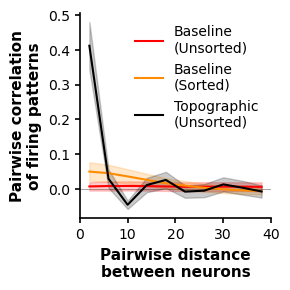

In [10]:
MAX_DIST = 40
BIN_WIDTH = 4.0
MIN_COUNT = 5

with open("distance_correlation_data.json") as f:
    data = json.load(f)

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

colors = {
    "baseline": "red",
    "baseline_sorted": "darkorange",
    "topo": "black",
}
labels = {
    "baseline": "Baseline\n(Unsorted)",
    "baseline_sorted": "Baseline\n(Sorted)",
    "topo": "Topographic\n(Unsorted)",
}

for key in ["baseline", "baseline_sorted", "topo"]:
    d = np.array(data[key]["distances"])
    c = np.array(data[key]["correlations"])

    mask = d <= MAX_DIST
    d, c = d[mask], c[mask]

    bins = np.arange(0, MAX_DIST + BIN_WIDTH, BIN_WIDTH)
    bin_idx = np.digitize(d, bins)

    bin_centers, means, variances = [], [], []
    for b in range(1, len(bins)):
        m = bin_idx == b
        if m.sum() > MIN_COUNT:
            bin_centers.append((bins[b - 1] + bins[b]) / 2)
            means.append(c[m].mean())
            variances.append(c[m].var())

    bin_centers = np.array(bin_centers)
    means = np.array(means)
    variances = np.array(variances)
    color = colors[key]

    ax.fill_between(
        bin_centers, means - variances, means + variances,
        color=color, alpha=0.2, zorder=1,
    )
    ax.plot(
        bin_centers, means,
        color=color, lw=1.5, zorder=2, label=labels[key],
    )

ax.axhline(0, color='gray', lw=0.5, ls='-', zorder=0)
ax.set_xlim(0, MAX_DIST)
ax.set_xlabel("Pairwise distance\nbetween neurons", fontsize=11, fontweight='bold')
ax.set_ylabel("Pairwise correlation\nof firing patterns", fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='both', labelsize=10, width=1.2)
ax.legend(frameon=False, fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig("distance_vs_correlation_styled.pdf", dpi=300, bbox_inches='tight')
plt.show()

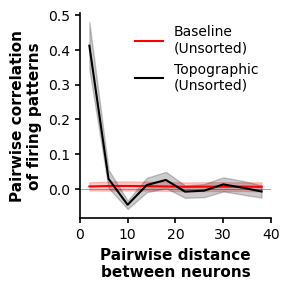

In [11]:
MAX_DIST = 40
BIN_WIDTH = 4.0
MIN_COUNT = 5

with open("distance_correlation_data.json") as f:
    data = json.load(f)

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

colors = {
    "baseline": "red",
    "topo": "black",
}
labels = {
    "baseline": "Baseline\n(Unsorted)",
    "topo": "Topographic\n(Unsorted)",
}

for key in ["baseline", "topo"]:
    d = np.array(data[key]["distances"])
    c = np.array(data[key]["correlations"])

    mask = d <= MAX_DIST
    d, c = d[mask], c[mask]

    bins = np.arange(0, MAX_DIST + BIN_WIDTH, BIN_WIDTH)
    bin_idx = np.digitize(d, bins)

    bin_centers, means, variances = [], [], []
    for b in range(1, len(bins)):
        m = bin_idx == b
        if m.sum() > MIN_COUNT:
            bin_centers.append((bins[b - 1] + bins[b]) / 2)
            means.append(c[m].mean())
            variances.append(c[m].var())

    bin_centers = np.array(bin_centers)
    means = np.array(means)
    variances = np.array(variances)
    color = colors[key]

    ax.fill_between(
        bin_centers, means - variances, means + variances,
        color=color, alpha=0.2, zorder=1,
    )
    ax.plot(
        bin_centers, means,
        color=color, lw=1.5, zorder=2, label=labels[key],
    )

ax.axhline(0, color='gray', lw=0.5, ls='-', zorder=0)
ax.set_xlim(0, MAX_DIST)
ax.set_xlabel("Pairwise distance\nbetween neurons", fontsize=11, fontweight='bold')
ax.set_ylabel("Pairwise correlation\nof firing patterns", fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='both', labelsize=10, width=1.2)
ax.legend(frameon=False, fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig("distance_vs_correlation_styled_unsorted.pdf", dpi=300, bbox_inches='tight')
plt.show()